<a href="https://colab.research.google.com/github/Bluedata-Consulting/GAAPB01-training-code-base/blob/main/SELFLEARNING_LangChain_Chain_reflection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reflection


In the context of LLM agent building, reflection refers to the process of prompting an LLM to observe its past steps (along with potential observations from tools/the environment) to assess the quality of the chosen actions.
This is then used downstream for things like re-planning, search, or evaluation.



This notebook demonstrates a very simple form of reflection in LangGraph.

In [1]:
model_name = "gemini-2.5-flash"

## Generate

For our example, we will create a "5 paragraph essay" generator. First, create the generator:


In [2]:
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are an essay assistant tasked with writing excellent 5-paragraph essays."
            " Generate the best essay possible for the user's request."
            " If the user provides critique, respond with a revised version of your previous attempts.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

from langchain.chat_models import init_chat_model
chatmodel = init_chat_model(model_name, model_provider="google_genai")


generate = prompt | chatmodel

In [3]:
essay = ""
request = HumanMessage(
    content="Write an essay on why the little prince is relevant in modern childhood"
)
for chunk in generate.stream({"messages": [request]}):
    print(chunk.content, end="")
    essay += chunk.content

Antoine de Saint-Exupéry’s whimsical tale, *The Little Prince*, has enchanted generations with its profound insights disguised in simple prose. While first published over seventy years ago, its gentle wisdom resonates with particular strength in the complexities of modern childhood. In an era often characterized by digital distractions, superficial connections, and a premature push towards pragmatism, *The Little Prince* offers a timeless antidote, nurturing imagination, emphasizing the value of deep relationships, and gently introducing children to the nuances of universal human emotions.

One of the most pressing challenges in modern childhood is the erosion of unbridled imagination and a sense of wonder. Children today are frequently immersed in highly structured activities, consumer culture, and constant screen time, which can inadvertently stifle the very creativity and open-mindedness that *The Little Prince* champions. The narrator’s frustration with "grown-ups" who see only a h

In [4]:
essay

'Antoine de Saint-Exupéry’s whimsical tale, *The Little Prince*, has enchanted generations with its profound insights disguised in simple prose. While first published over seventy years ago, its gentle wisdom resonates with particular strength in the complexities of modern childhood. In an era often characterized by digital distractions, superficial connections, and a premature push towards pragmatism, *The Little Prince* offers a timeless antidote, nurturing imagination, emphasizing the value of deep relationships, and gently introducing children to the nuances of universal human emotions.\n\nOne of the most pressing challenges in modern childhood is the erosion of unbridled imagination and a sense of wonder. Children today are frequently immersed in highly structured activities, consumer culture, and constant screen time, which can inadvertently stifle the very creativity and open-mindedness that *The Little Prince* champions. The narrator’s frustration with "grown-ups" who see only 

### Reflect

In [5]:
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a teacher grading an essay submission. Generate critique and recommendations for the user's submission."
            " Provide detailed recommendations, including requests for length, depth, style, etc.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)
from langchain.chat_models import init_chat_model
chatmodel = init_chat_model(model_name, model_provider="google_genai")
reflect = reflection_prompt | chatmodel

In [6]:
reflection = ""
for chunk in reflect.stream({"messages": [HumanMessage(content=request.content + "\n" + essay)]}):
    print(chunk.content, end="")
    reflection += chunk.content

This is a well-structured and thoughtful essay that effectively argues for the enduring relevance of *The Little Prince* in modern childhood. You demonstrate a strong understanding of the text and connect its themes cogently to contemporary challenges.

Here's a breakdown of your essay's strengths and areas for recommendation:

---

### **Overall Assessment:**

**Grade: A- / B+**

This essay is a strong submission. You have a clear thesis, good organization, and effectively use examples from *The Little Prince* to support your points. Your writing is clear, concise, and academic. To elevate it further, focus on deepening your analysis and making some of your connections even more explicit and nuanced.

---

### **Strengths:**

1.  **Clear Thesis Statement:** Your introduction clearly sets out your argument that *The Little Prince* acts as a "timeless antidote" to modern childhood's complexities by "nurturing imagination, emphasizing the value of deep relationships, and gently introduci

In [7]:
reflection

'This is a well-structured and thoughtful essay that effectively argues for the enduring relevance of *The Little Prince* in modern childhood. You demonstrate a strong understanding of the text and connect its themes cogently to contemporary challenges.\n\nHere\'s a breakdown of your essay\'s strengths and areas for recommendation:\n\n---\n\n### **Overall Assessment:**\n\n**Grade: A- / B+**\n\nThis essay is a strong submission. You have a clear thesis, good organization, and effectively use examples from *The Little Prince* to support your points. Your writing is clear, concise, and academic. To elevate it further, focus on deepening your analysis and making some of your connections even more explicit and nuanced.\n\n---\n\n### **Strengths:**\n\n1.  **Clear Thesis Statement:** Your introduction clearly sets out your argument that *The Little Prince* acts as a "timeless antidote" to modern childhood\'s complexities by "nurturing imagination, emphasizing the value of deep relationships, 

### Repeat

And... that's all there is too it! You can repeat in a loop for a fixed number of steps, or use an LLM (or other check) to decide when the finished product is good enough.

In [8]:
for chunk in generate.stream(
    {"messages": [request, AIMessage(content=essay), HumanMessage(content=reflection)]}
):
    print(chunk.content, end="")

Antoine de Saint-Exupéry’s whimsical tale, *The Little Prince*, has enchanted generations with its profound insights disguised in simple prose. While first published over seventy years ago, its gentle wisdom resonates with particular strength in the complexities of modern childhood. In an era often characterized by digital distractions, superficial connections, and a premature push towards pragmatism, *The Little Prince* offers a timeless antidote, nurturing imagination, emphasizing the value of deep relationships, and gently introducing children to the nuances of universal human emotions, thereby equipping them with a crucial counter-narrative to contemporary pressures.

One of the most pressing challenges in modern childhood is the erosion of unbridled imagination and a sense of wonder. Children today are frequently immersed in highly structured activities, consumer culture, and constant screen time, which can inadvertently stifle the very creativity and open-mindedness that *The Lit

## Define graph

Now that we've shown each step in isolation, we can wire it up in a graph.

In [9]:
from typing import List, Sequence

from langgraph.graph import END, MessageGraph, START
import time

async def generation_node(state: Sequence[BaseMessage]):
    return await generate.ainvoke({"messages": state})


async def reflection_node(messages: Sequence[BaseMessage]) -> List[BaseMessage]:
    # Other messages we need to adjust
    cls_map = {"ai": HumanMessage, "human": AIMessage}
    time.sleep(30)
    # First message is the original user request. We hold it the same for all nodes
    translated =  [
        cls_map[msg.type](content=msg.content) for msg in messages[1:]
    ]
    res = await reflect.ainvoke({"messages": translated})
    # We treat the output of this as human feedback for the generator
    return HumanMessage(content=res.content)


builder = MessageGraph()
builder.add_node("generate", generation_node)
builder.add_node("reflect", reflection_node)
builder.add_edge(START, "generate")


def should_continue(state: List[BaseMessage]):
    if len(state) > 6:
        # End after 3 iterations
        return END
    return "reflect"


builder.add_conditional_edges("generate", should_continue)
builder.add_edge("reflect", "generate")
graph = builder.compile()

/tmp/ipykernel_6766/2644100384.py:23: LangGraphDeprecatedSinceV10: MessageGraph is deprecated in LangGraph v1.0.0, to be removed in v2.0.0. Please use StateGraph with a `messages` key instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  builder = MessageGraph()


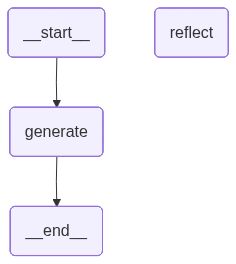

In [10]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [11]:
async for event in graph.astream(
    [
        HumanMessage(
            content="Generate an essay on the topicality of The Little Prince and its message in modern life"
        )
    ],
):
    ChatPromptTemplate.from_messages(event).pretty_print()
    print(list(event.values())[0].content)
    print("---")

================================ Human Message =================================

generate
Antoine de Saint-Exupéry’s *The Little Prince*, first published in 1943, has enchanted generations with its deceptively simple narrative and whimsical illustrations. Far from being a mere children’s story, this novella offers a profound meditation on life, love, and loss. Decades after its creation, its messages resonate with startling clarity, making it an exceptionally topical work for contemporary audiences. The book’s core themes—the vital importance of imagination, the profound value of genuine human connection, and a sharp critique of adult materialism—remain profoundly relevant in our increasingly complex and often disconnected modern world.

One of the most striking aspects of *The Little Prince* is its fervent defense of imagination and the unique perspective of childhood. In an era dominated by screens, data, and a relentless push towards "practical" skills, the ability to see beyond th

In [12]:
list(event.values())[0].content

"Thank you again for your incredibly kind words and continued encouragement! It's truly motivating to receive such positive feedback, especially after putting in the effort to revise.\n\nI'm very grateful for your insightful guidance; it genuinely helped me see the essay's potential and how to unlock it. Your specific recommendations were instrumental in transforming the piece, and I learned a great deal about deepening analysis and integrating contemporary relevance more effectively.\n\nI will certainly keep your generous offer of future assistance in mind. It's been a pleasure working with you!"

## Conclusion

Now that you've applied reflection to an LLM agent, I'll note one thing: self-reflection is inherently cyclic: it is much more effective if the reflection step has additional context or feedback (from tool observations, checks, etc.). If, like in the scenario above, the reflection step simply prompts the LLM to reflect on its output, it can still benefit the output quality (since the LLM then has multiple "shots" at getting a good output), but it's less guaranteed.
